In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


**Avaliação do dataset Iris com SVM no Kaggle**

1. Importação das bibliotecas do experimento
Aqui entram as bibliotecas específicas para este trabalho:

pandas: manipulação do dataset.
train_test_split: divisão dos dados em treino e teste.
SVC: implementação do modelo SVM (Support Vector Machine) do scikit-learn.
accuracy_score: métrica para avaliar o desempenho do modelo.

In [15]:
#Importar bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score

2. Carregamento do dataset
Carrega o dataset Iris (arquivo Iris.csv) em um DataFrame do pandas e imprime seu conteúdo completo para inspeção inicial. O dataset contém medidas de sépalas e pétalas de 3 espécies de flores (Iris-setosa, Iris-versicolor, Iris-virginica).

In [16]:
df = pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv')
print(df)

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-setosa  
..              ...  
145  

3. Separação entre variáveis preditoras (X) e alvo (y)
X: contém apenas as colunas numéricas de medidas (sépala/pétala), removendo Id (irrelevante para o modelo) e Species (é o que queremos prever).
y: contém apenas a coluna Species, ou seja, o rótulo/classe que o modelo deve aprender a prever.

In [17]:
#X ira retirar a coluna especie e id( ira considerar apenas as demais colunas)
X= df.drop(columns=['Id', 'Species'])

#Y ira considerar apenas a coluna Species
y= df['Species']

print(X)

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0              5.1           3.5            1.4           0.2
1              4.9           3.0            1.4           0.2
2              4.7           3.2            1.3           0.2
3              4.6           3.1            1.5           0.2
4              5.0           3.6            1.4           0.2
..             ...           ...            ...           ...
145            6.7           3.0            5.2           2.3
146            6.3           2.5            5.0           1.9
147            6.5           3.0            5.2           2.0
148            6.2           3.4            5.4           2.3
149            5.9           3.0            5.1           1.8

[150 rows x 4 columns]


4. Divisão em treino e teste
Divide o dataset em 80% para treino e 20% para teste, usando random_state=42 (garante reprodutibilidade) e stratify=y (mantém a proporção original das 3 espécies em ambos os conjuntos).

In [18]:
#divide o conjunto de dados em treino e teste ( train and test) ( 80% treino e 20% teste)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state = 42, stratify = y)

5. Criação do modelo
Instancia um classificador SVM (Support Vector Machine) com kernel linear, adequado para este problema já que as classes do Iris são quase linearmente separáveis.

In [19]:
#Crie o modelo SVM (usando o kermel linear)

model = SVC (kernel = 'linear')

6. Treinamento do modelo
Ajusta (treina) o modelo SVM usando apenas os dados de treino (X_train, y_train), fazendo com que ele aprenda a fronteira de decisão entre as 3 espécies.

In [20]:
#treine o modelo com os dados de treino

model.fit(X_train, y_train)

SVC(kernel='linear')

7. Predições no conjunto de teste
Usa o modelo treinado para prever a espécie das amostras que ele nunca viu (X_test), gerando o vetor y_pred com as classes previstas.

In [21]:
#faça as previsões nos dados teste

y_pred = model.predict(X_test)

8. Avaliação da acurácia
Compara as previsões (y_pred) com os valores reais (y_test) e calcula a acurácia do modelo, exibida em porcentagem.

In [22]:
#Calcule a acuracia

accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy * 100:.2f}%")


Acurácia do modelo: 100.00%


9. Comparação lado a lado
Imprime, lado a lado, os valores previstos pelo modelo e os valores reais do conjunto de teste, permitindo uma checagem manual e rápida dos acertos e erros.

In [23]:
#exibe as previçoes de teste e valores reais

print("valores predito:", y_pred)
print("valores reais:", y_test)

valores predito: ['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']
valores reais: 38         Iris-setosa
127     Iris-virginica
57     Iris-versicolor
93     Iris-versicolor
42         Iris-setosa
56     Iris-versicolor
22         Iris-setosa
20         Iris-setosa
147     Iris-virginica
84     Iris-versicolor
107     Iris-virginica
141     Iris-virginica
104     Iris-virginica
51     Iris-versicolor
7          Iris-setosa
49         Iris-setosa
14         Iris-setosa
69     Iris-versicolor
63     Iris-versicolor
138     Iris-virginica
10       

11. Verificação final: gráficos de avaliação
Para concluir a análise, geramos dois gráficos que ajudam a validar visualmente o desempenho do modelo SVM treinado:

Matriz de confusão — mostra quantos acertos e erros o modelo teve para cada espécie.
Dispersão Comprimento x Largura da Pétala (Real x Previsto) — compara visualmente as classes reais e as classes previstas no espaço das duas features mais discriminantes do dataset Iris (pétala), facilitando ver onde o modelo eventualmente errou.

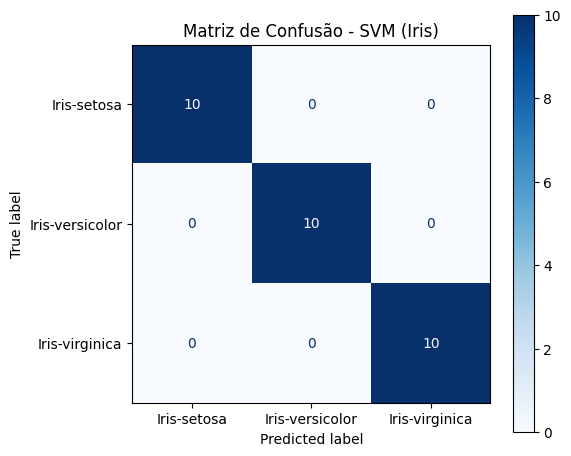

In [24]:
# Gráfico 1 - Matriz de confusão
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Matriz de Confusão - SVM (Iris)")
plt.tight_layout()
plt.show()

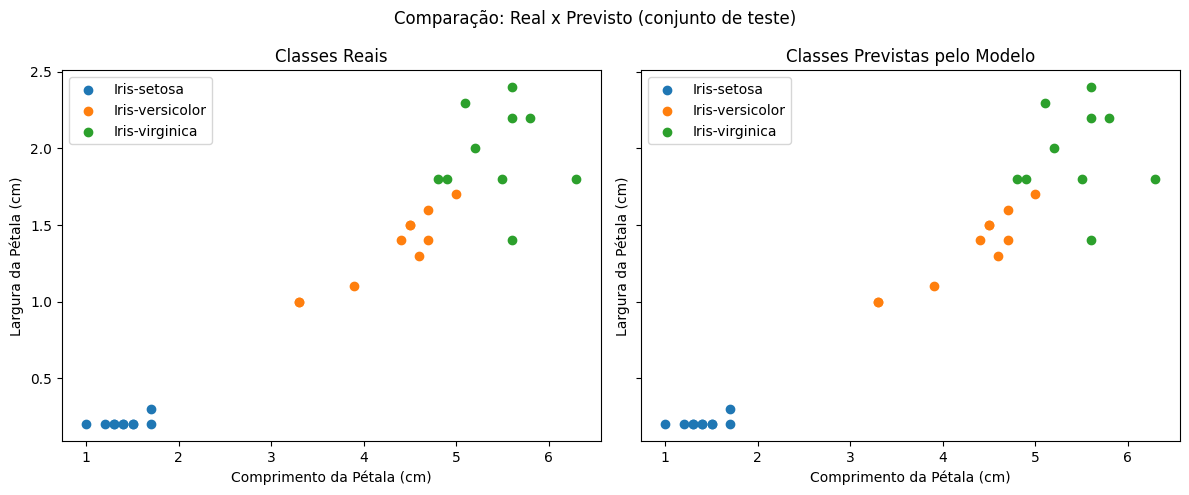

In [25]:
# Gráfico 2 - Dispersão: valores reais x valores previstos (pétala)
import matplotlib.pyplot as plt

# Reconstrói as colunas de pétala do conjunto de teste para o plot
petal_length = X_test["PetalLengthCm"].values
petal_width = X_test["PetalWidthCm"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for species in y.unique():
    mask_real = (y_test.values == species)
    axes[0].scatter(petal_length[mask_real], petal_width[mask_real], label=species)

    mask_pred = (y_pred == species)
    axes[1].scatter(petal_length[mask_pred], petal_width[mask_pred], label=species)

axes[0].set_title("Classes Reais")
axes[1].set_title("Classes Previstas pelo Modelo")
for ax in axes:
    ax.set_xlabel("Comprimento da Pétala (cm)")
    ax.set_ylabel("Largura da Pétala (cm)")
    ax.legend()

plt.suptitle("Comparação: Real x Previsto (conjunto de teste)")
plt.tight_layout()
plt.show()